In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams.update({
    "font.size": 14,                 # global font size
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),
})


In [5]:
# ==========================================
# 1. Helper functions
# ==========================================

def read_dos(data_dir, filename="spectra_dos.csv"):
    file_path = os.path.join(data_dir, filename)
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return None
    df = pd.read_csv(file_path)
    if df.empty:
        print(f"Warning: Empty file {file_path}")
        return None
    df = df.sort_values('omega')
    return df

def get_dos_at_omega0(df):
    omega = df['omega'].to_numpy()
    dos = df['DOS'].to_numpy()
    idx0 = int(np.argmin(np.abs(omega)))
    dos0 = dos[idx0]
    err0 = np.nan
    if 'DOS_Error' in df.columns:
        err0 = df['DOS_Error'].to_numpy()[idx0]
    return dos0, err0, float(omega[idx0])


In [6]:
# ==========================================
# 2. Main loop
# ==========================================

T_list = [0.0001, 0.0005, 0.001, 0.005, 0.01,
          0.015, 0.02, 0.025, 0.03, 0.04, 0.06]

results = {
    "T": [],
    "N0": [],
    "N0_err": []
}
spectra = []

base_dir = "./"  # set to your data root if needed

print(f"Starting DOS analysis for {len(T_list)} temperatures...")

for T in T_list:
    dir_name = f"T_{T}"
    data_dir = os.path.join(base_dir, dir_name)

    print(f"Processing {dir_name}...", end='\r')

    df = read_dos(data_dir)
    if df is None:
        continue

    omega = df['omega'].to_numpy()
    dos = df['DOS'].to_numpy()
    dos_err = df['DOS_Error'].to_numpy() if 'DOS_Error' in df.columns else None

    spectra.append({
        'T': T,
        'omega': omega,
        'dos': dos,
        'dos_err': dos_err
    })

    n0, n0_err, omega0 = get_dos_at_omega0(df)
    results['T'].append(T)
    results['N0'].append(n0)
    results['N0_err'].append(n0_err)

print("\nAnalysis complete.")

for key in results:
    results[key] = np.array(results[key])


Starting DOS analysis for 11 temperatures...

Analysis complete.


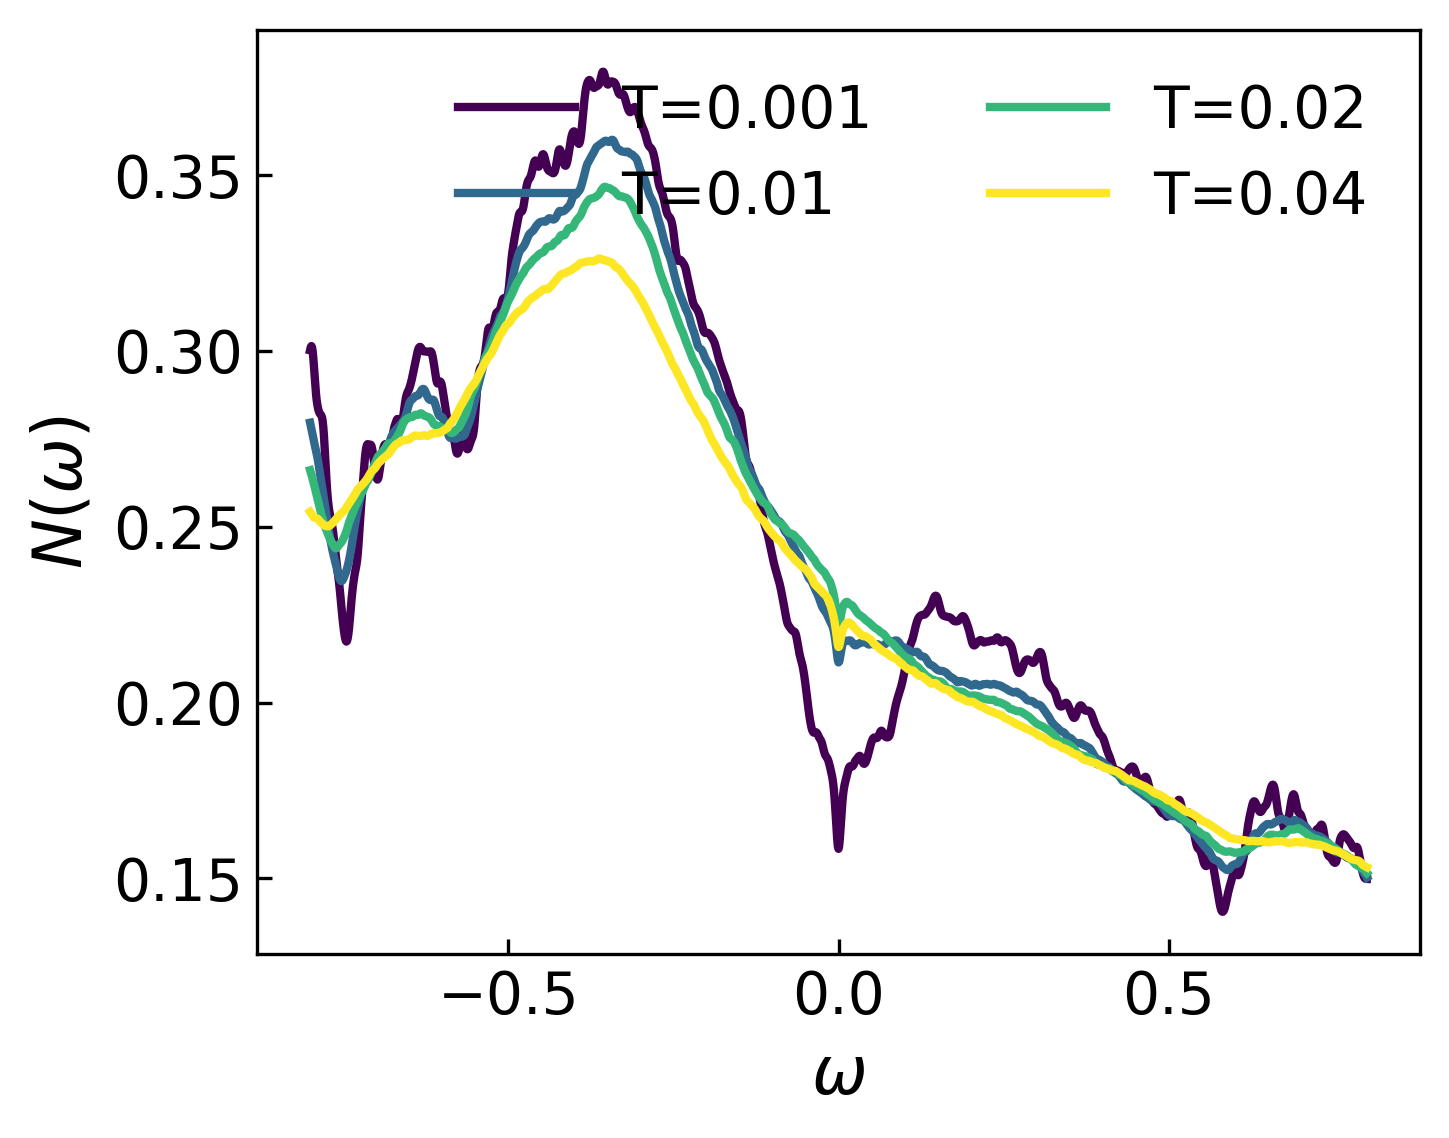

In [7]:
# ==========================================
# 3. N(omega) vs omega for different T
# ==========================================

fig, ax = plt.subplots(dpi=300)
colors = plt.cm.viridis(np.linspace(0, 1, len(spectra)))

for i, spec in enumerate(spectra):
    ax.plot(spec['omega'], spec['dos'], color=colors[i], label=rf"T={spec['T']:g}")

ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$N(\omega)$')
ax.legend(frameon=False, ncol=2)
plt.show()


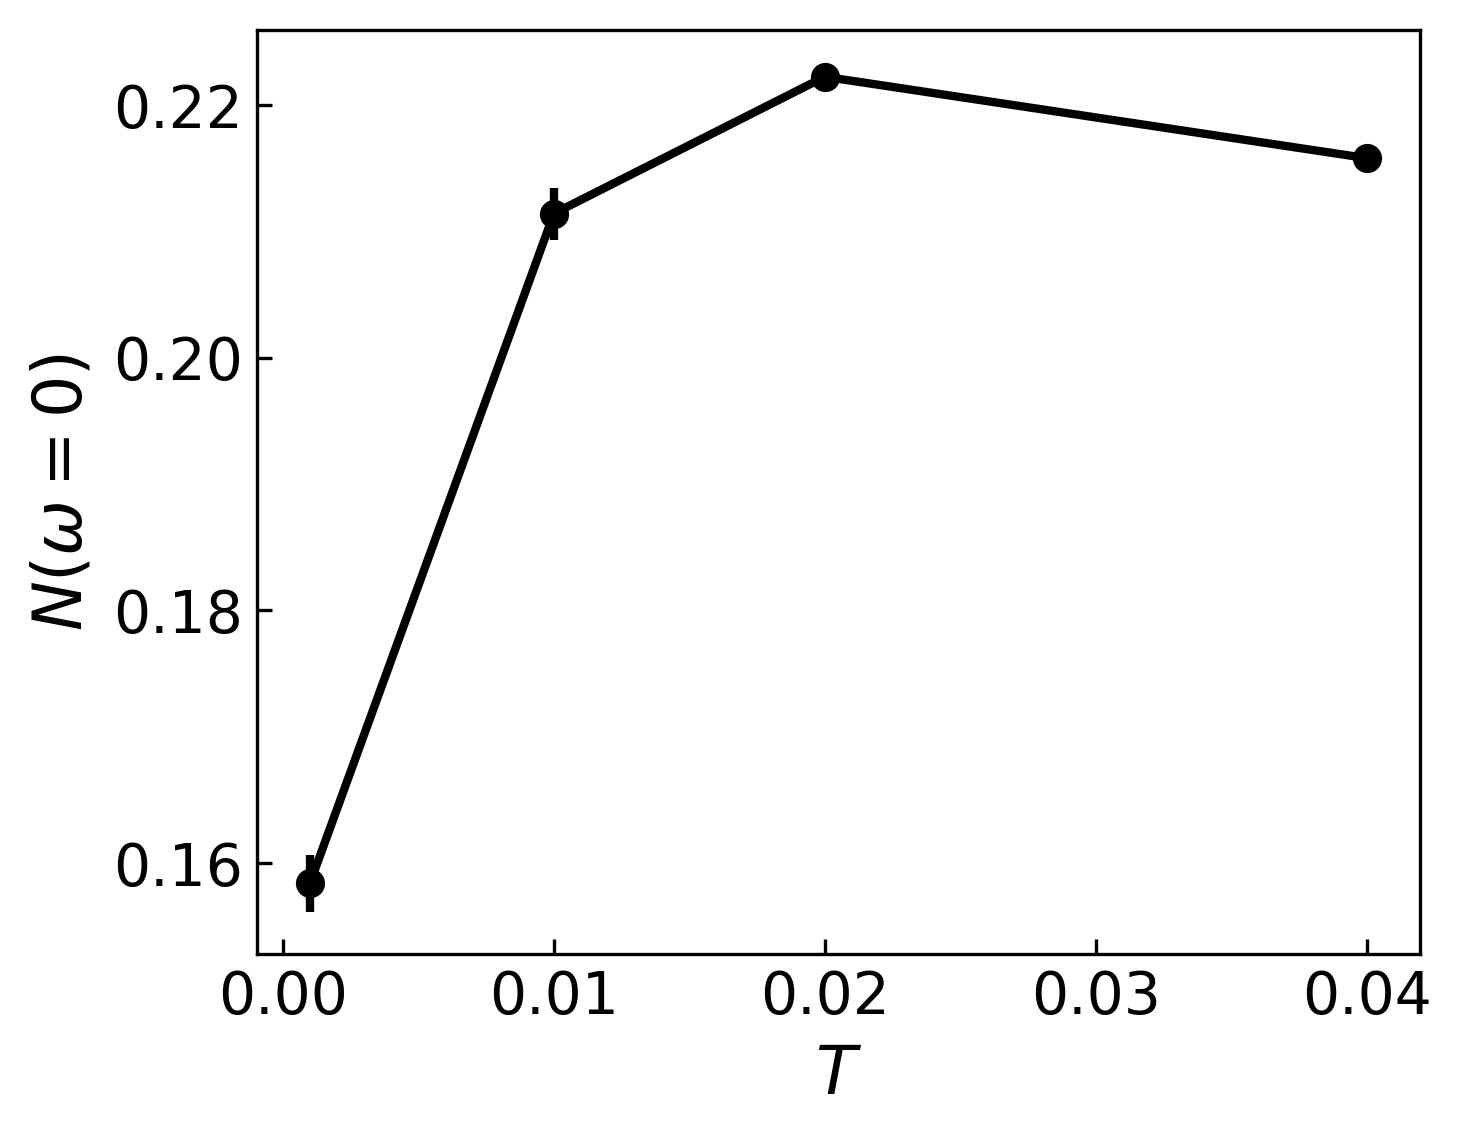

In [8]:
# ==========================================
# 4. N(omega=0) vs T
# ==========================================

t_vals = results['T'].copy()
n0_vals = results['N0'].copy()
n0_err = results['N0_err'].copy()

mask = np.isfinite(t_vals) & np.isfinite(n0_vals)
t_vals = t_vals[mask]
n0_vals = n0_vals[mask]
n0_err = n0_err[mask]

fig, ax = plt.subplots(dpi=300)
if np.any(np.isfinite(n0_err)):
    ax.errorbar(t_vals, n0_vals, yerr=n0_err, fmt='-o', color='black')
else:
    ax.plot(t_vals, n0_vals, '-o', color='black')

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$N(\omega=0)$')
plt.show()


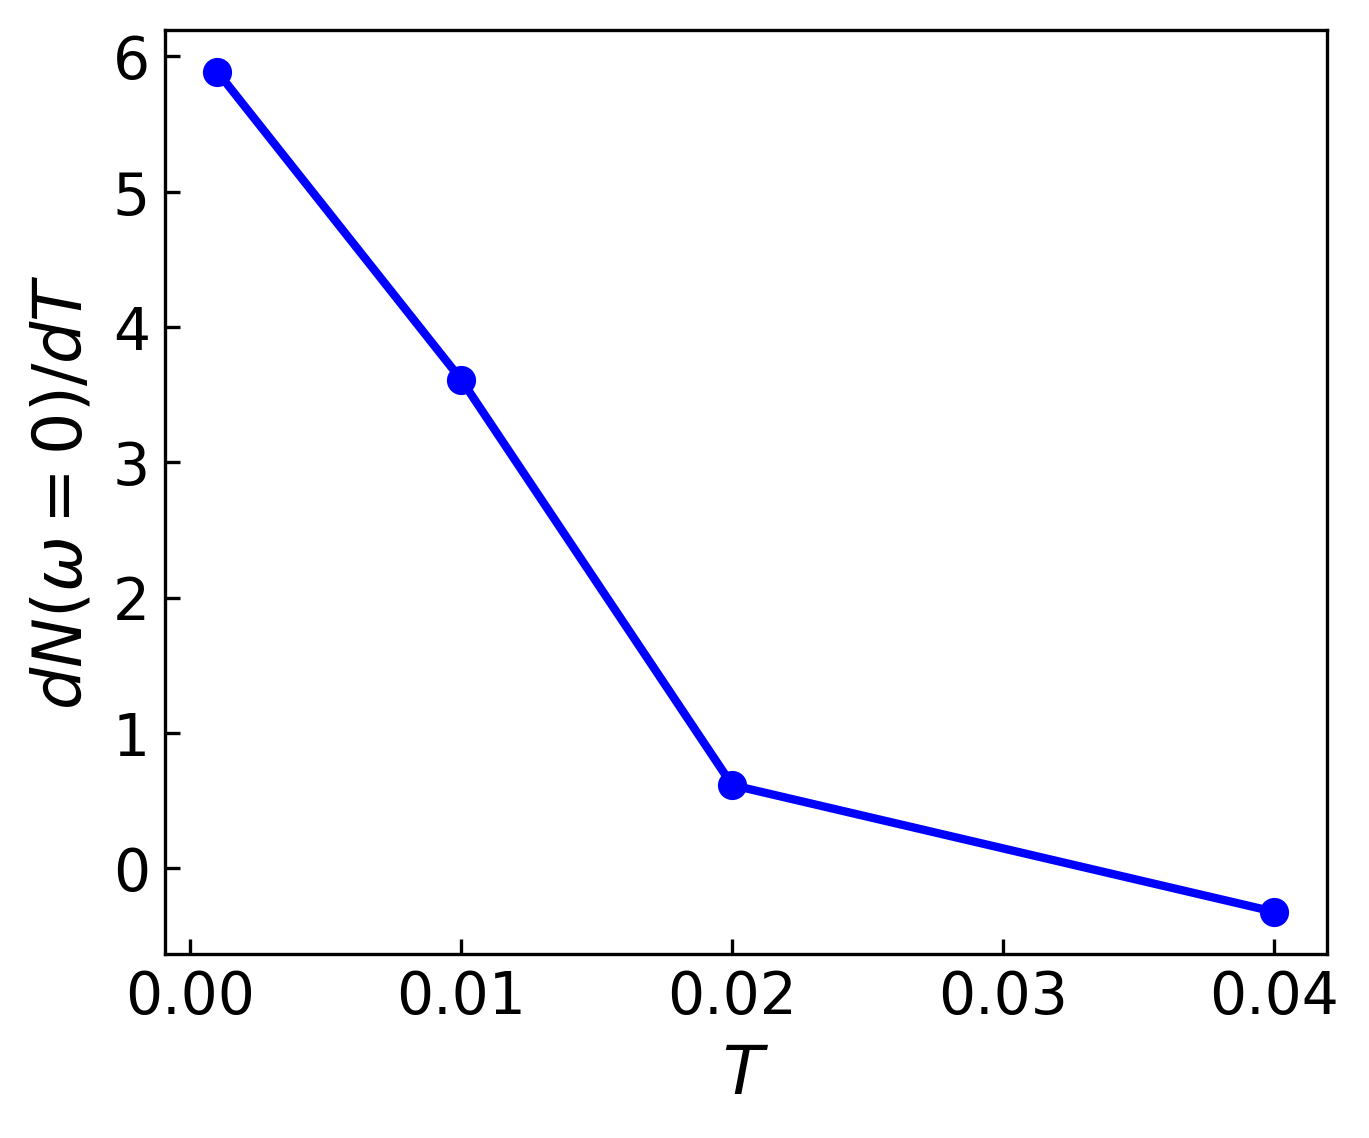

In [9]:
# ==========================================
# 5. dN(omega=0)/dT vs T
# ==========================================

t_vals = results['T'].copy()
n0_vals = results['N0'].copy()

mask = np.isfinite(t_vals) & np.isfinite(n0_vals)
t_vals = t_vals[mask]
n0_vals = n0_vals[mask]

sort_idx = np.argsort(t_vals)
t_vals = t_vals[sort_idx]
n0_vals = n0_vals[sort_idx]

if len(t_vals) < 2:
    print("Not enough points to compute dN/dT.")
else:
    dN_dT = np.gradient(n0_vals, t_vals)

    fig, ax = plt.subplots(dpi=300)
    ax.plot(t_vals, dN_dT, '-o', color='blue')
    ax.set_xlabel(r'$T$')
    ax.set_ylabel(r'$dN(\omega=0)/dT$')
    plt.show()
